# Importing some libraries

In [27]:
# # Install the darts library
# !pip install darts

#!pip install pytorch-lightning
#!pip install u8darts
#!pip install optuna -q

In [4]:
# Standard Libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np
from sklearn.model_selection import ParameterGrid

In [5]:
# Darts functions
from darts.timeseries import TimeSeries
from darts.utils.timeseries_generation import datetime_attribute_timeseries
from darts.dataprocessing.transformers import Scaler
from darts.models import RNNModel

* We are going to use the **New York City energy/utility demand** dataset. This is a great dataset for time series forecasting since it has clear seasonality, Exogenous covariates (temperature, marketing, holidays), and Enough history to train a decent sequence model.

# Data Preparation

- **`parse_dates=True`** — converts the "Date" column from string to proper `datetime` objects.
- **`dayfirst=False`** — tells pandas dates are in MM/DD format, not DD/MM. Avoids misreading.
- **`index_col="Date"`** — we set Date as the index since it is the time axis.

In [6]:
df = pd.read_csv("nyc_data.csv", index_col="Date", parse_dates=True, dayfirst=False)
df.index.freq = pd.infer_freq(df.index)
# Set the frequency of the DataFrame to daily ("D")
df = df.asfreq("D")
df.head(2)

,Demand,Easter,Thanksgiving,Christmas,Temperature,Marketing
Date,,,,,,
2015-01-01,720.000885,0,0,0,3.68,41.305
2015-01-02,581.276773,0,0,0,4.73,131.574


In [7]:
# Information about the df
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2192 entries, 2015-01-01 to 2020-12-31
Freq: D
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Demand        2192 non-null   float64
 1   Easter        2192 non-null   int64  
 2   Thanksgiving  2192 non-null   int64  
 3   Christmas     2192 non-null   int64  
 4   Temperature   2192 non-null   float64
 5   Marketing     2192 non-null   float64
dtypes: float64(3), int64(3)
memory usage: 119.9 KB


# Exploratory Data Analysis

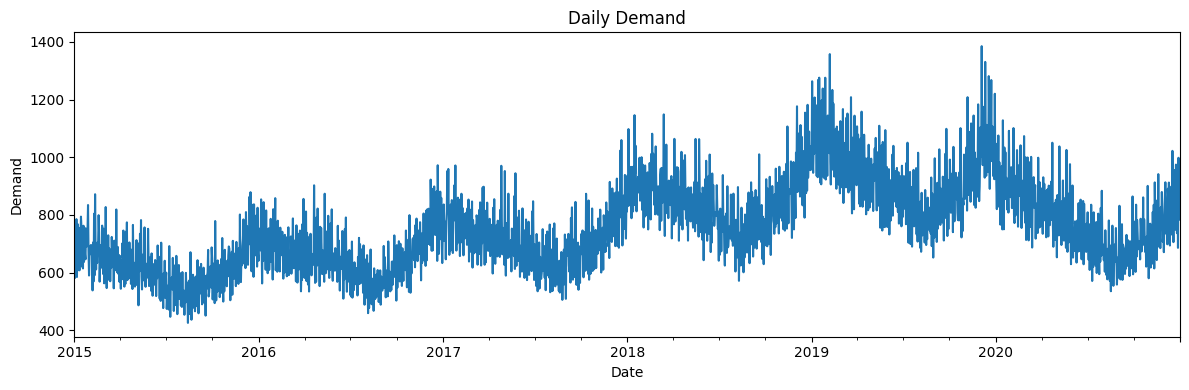

In [8]:
df['Demand'].plot(title='Daily Demand', figsize=(12, 4), ylabel='Demand')
plt.tight_layout()
plt.show()

* The following plot shows the average daily demand for each month, with a horizontal line per month representing the monthly mean. Lets you spot annual seasonality — e.g. whether demand peaks in summer/winter.

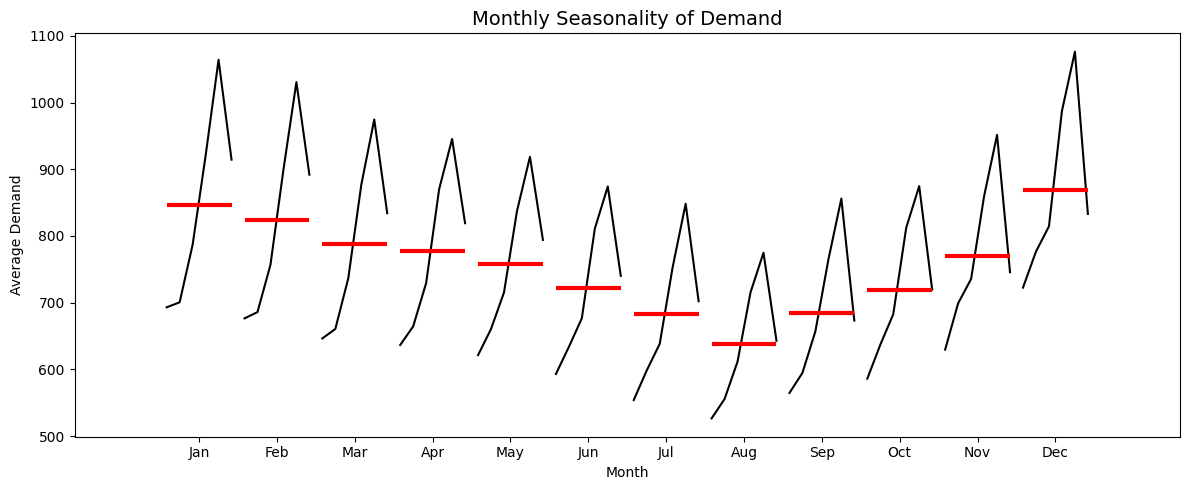

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
month_plot(df['Demand'].resample('ME').mean(), ax=ax)
ax.set_title('Monthly Seasonality of Demand', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Average Demand')
plt.tight_layout()
plt.show()

* The following code decomposes `Demand` into trend, seasonality, and residuals using a **multiplicative model** with a **yearly period (365 days)**, then plots all components in a single figure with a title and clean layout.

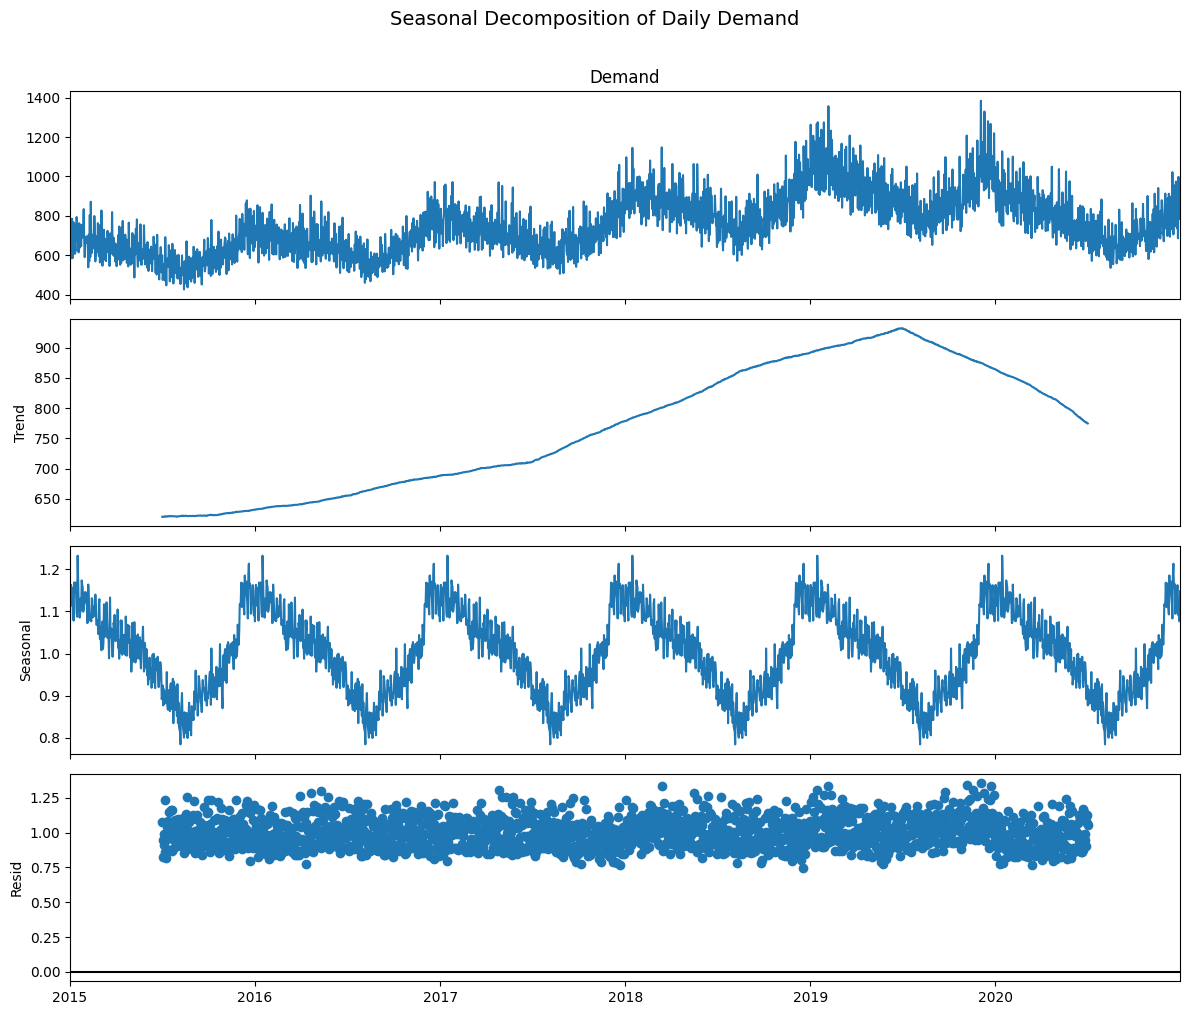

In [10]:
decomposition = seasonal_decompose(df['Demand'], model='multiplicative', period=365)

fig = decomposition.plot()
fig.set_size_inches(12, 10)
fig.suptitle('Seasonal Decomposition of Daily Demand', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

* The ACF stays strongly positive and decays very slowly across many lags, which suggests the NYC energy demand series is highly persistent and likely non-stationary (strong trend/seasonality structure). The PACF shows a few dominant early lags plus periodic spikes at regular intervals, which is a classic sign of recurring seasonal cycles — likely daily and/or weekly demand patterns.

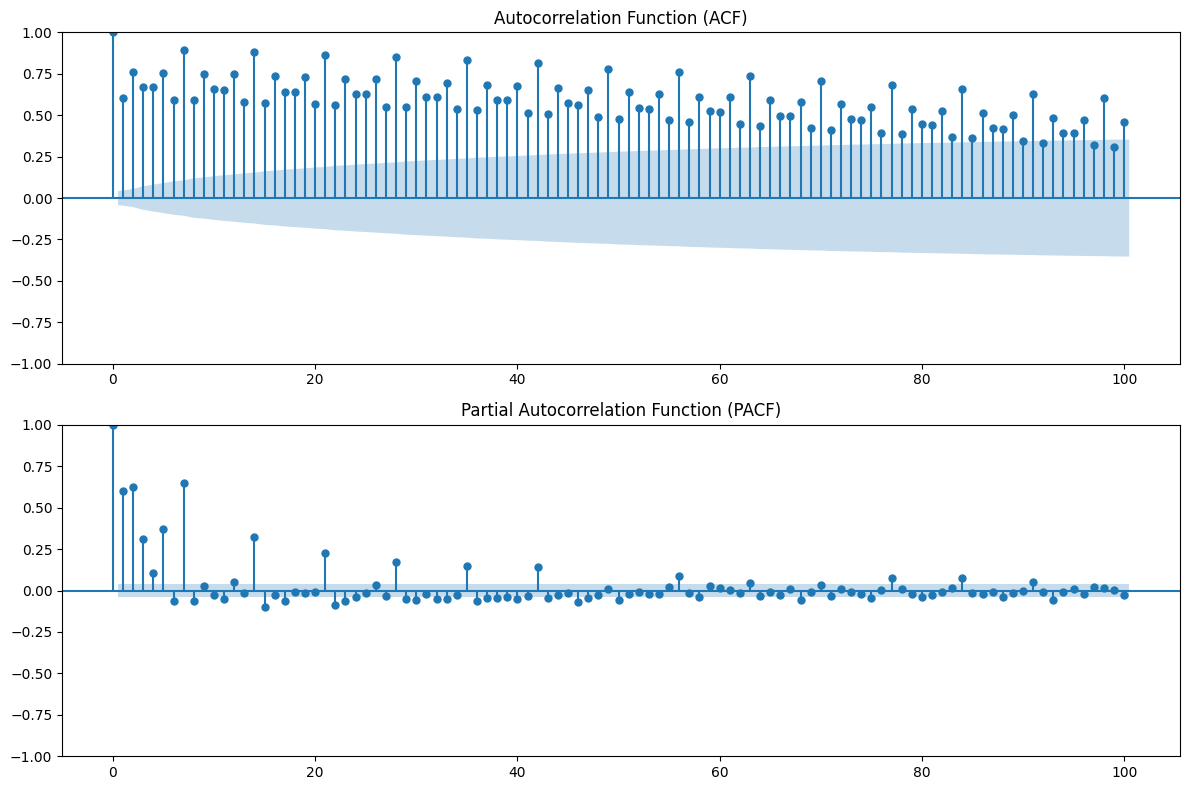

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['Demand'], lags=100, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(df['Demand'], lags=100, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

# Data Preparation & Modelling Pipeline

`Raw DataFrame` → `TimeSeries conversion` → `Feature engineering` → `Scaling` → `LSTM training` → `Hyperparameter tuning (Optuna)` → `Final model training` → `Forecast`

In [12]:
series = TimeSeries.from_series(df['Demand'])
covariates = TimeSeries.from_dataframe(df.iloc[:, 1:])

`Raw DataFrame` → `TimeSeries conversion` → `Feature engineering` → `Scaling`✅ → `LSTM training` → `Hyperparameter tuning (Optuna)` → `Final model training` → `Forecast`

In [18]:
date_range = pd.date_range(start=series.start_time(), freq=series.freq_str, periods=len(df))

year_series    = datetime_attribute_timeseries(date_range, attribute="year",    one_hot=False)
month_series   = datetime_attribute_timeseries(date_range, attribute="month",   one_hot=True)
weekday_series = datetime_attribute_timeseries(date_range, attribute="weekday", one_hot=True)

In [19]:
scaler_target = Scaler()
scaler_covariates = Scaler()

In [20]:
demand_transformed = scaler_target.fit_transform(series)

In [21]:
covariates = covariates.stack(year_series)
covariates_transformed = scaler_covariates.fit_transform(covariates)
covariates_transformed = covariates_transformed.stack(month_series)
covariates_transformed = covariates_transformed.stack(weekday_series)

# LSTM model development

`Raw DataFrame` → `TimeSeries conversion` → `Feature engineering` → `Scaling` → `LSTM training`✅ → `Hyperparameter tuning (Optuna)` → `Final model training` → `Forecast`

In [22]:
forecasting_horizon = 7  # Number of periods to forecast into the future
input_chunk_length = 70  # Number of past periods used for making predictions

training_length = forecasting_horizon + input_chunk_length  # Total length of the training window

In [23]:
model = RNNModel(model="LSTM",
                 hidden_dim=20,
                 n_rnn_layers=2,
                 dropout=0.1,
                 n_epochs=10,
                 optimizer_kwargs={"lr": 0.003},
                 random_state=43,
                 training_length=77,
                 input_chunk_length=70,
                 pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]}
                 )

model.fit(demand_transformed, future_covariates=covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  7.2 K │ train │     0 │
│ 6 │ V               │ Linear           │     21 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 K                                                                                                
Total estimated model params size (MB): 0.058                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


RNNModel(model=LSTM, hidden_dim=20, n_rnn_layers=2, dropout=0.1, training_length=77, n_epochs=10, optimizer_kwargs={'lr': 0.003}, random_state=43, input_chunk_length=70, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

# Cross Validation

In [24]:
cv = model.historical_forecasts(series=demand_transformed,
                                future_covariates=covariates_transformed,
                                start=len(df) - 180,
                                forecast_horizon=forecasting_horizon,
                                stride=7,
                                retrain=True,
                                last_points_only=False,
                                verbose=True)

historical forecasts:   0%|          | 0/25 [00:00<?, ?it/s]INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │  7.2 K │ train │     0 │
│ 6 │ V               │ Linear           │     21 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 7.2 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 7.2 K                                                                                                
Total estimated model params size (MB): 0.058                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


...

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

historical forecasts: 100%|██████████| 25/25 [04:19<00:00, 10.36s/it]


In [25]:
rmse_cv = []

for i in range(len(cv)):
    predictions = TimeSeries.to_series(scaler_target.inverse_transform(cv[i]))

    start = predictions.index.min()
    end = predictions.index.max()

    actuals = df['Demand'][start:end]

    error_cv = np.sqrt(mean_squared_error(actuals, predictions))
    rmse_cv.append(error_cv)

print(f"Mean RMSE: {np.mean(rmse_cv):.2f}")

Mean RMSE: 64.61


# Parameter Tuning

`Raw DataFrame` → `TimeSeries conversion` → `Feature engineering` → `Scaling` → `LSTM training` → `Hyperparameter tuning (Optuna)`✅ → `Final model training` → `Forecast`

In [ ]:
import optuna
#from optuna.integration import PyTorchLightningPruningCallback

def objective(trial):
    model = RNNModel(
        model="LSTM",
        hidden_dim=trial.suggest_categorical("hidden_dim", [10, 20, 40]),
        n_rnn_layers=trial.suggest_int("n_rnn_layers", 1, 3),
        dropout=trial.suggest_float("dropout", 0.0, 0.3),
        n_epochs=trial.suggest_categorical("n_epochs", [5, 10, 15]),
        optimizer_kwargs={"lr": trial.suggest_float("lr", 1e-4, 1e-2, log=True)},
        training_length=77,
        input_chunk_length=70,
        random_state=43,
        pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]}
    )

    model.fit(demand_transformed, future_covariates=covariates_transformed)

    cv = model.historical_forecasts(series=demand_transformed,
                                    future_covariates=covariates_transformed,
                                    start=len(df) - 180,
                                    forecast_horizon=forecasting_horizon,
                                    stride=7,
                                    retrain=False,
                                    last_points_only=False,
                                    verbose=False)

    rmse_cv = []
    for i in range(len(cv)):
        predictions = TimeSeries.to_series(scaler_target.inverse_transform(cv[i]))
        actuals = df['Demand'][predictions.index.min():predictions.index.max()]
        rmse_cv.append(np.sqrt(mean_squared_error(actuals, predictions)))

    return np.mean(rmse_cv)


study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best RMSE: {study.best_value:.2f}")
print(f"Best params: {study.best_params}")

In [28]:
print(f"Best RMSE: {study.best_value:.2f}")
print(f"Best params: {study.best_params}")

Best RMSE: 29.41
Best params: {'hidden_dim': 40, 'n_rnn_layers': 3, 'dropout': 0.07415359407167599, 'n_epochs': 15, 'lr': 0.006976027595104927}


In [ ]:
# study.trials_dataframe().sort_values('value')

# Predict the future

`Raw DataFrame` → `TimeSeries conversion` → `Feature engineering` → `Scaling` → `LSTM training` → `Hyperparameter tuning (Optuna)` → `Final model training`✅ → `Forecast`

In [29]:
# Extract best params from Optuna
n_rnn_layers = study.best_params['n_rnn_layers']
hidden_dim = study.best_params['hidden_dim']
dropout = study.best_params['dropout']
lr = study.best_params['lr']
n_epochs = study.best_params['n_epochs']

# Load future covariates
future_df = pd.read_csv("future.csv", index_col="Date", parse_dates=True)

# Combine training and future covariates
X_train = df.iloc[:, 1:]
X_future = future_df.iloc[:, 1:]
X = pd.concat([X_train, X_future])

# Convert to TimeSeries
covariates = TimeSeries.from_dataframe(X)

# Datetime features over extended date range
date_range = pd.date_range(start=series.start_time(), freq=series.freq_str, periods=len(X))
year_series    = datetime_attribute_timeseries(date_range, attribute="year",    one_hot=False)
month_series   = datetime_attribute_timeseries(date_range, attribute="month",   one_hot=True)
weekday_series = datetime_attribute_timeseries(date_range, attribute="weekday", one_hot=True)

# Rescale everything
scaler_target     = Scaler()
scaler_covariates = Scaler()

demand_transformed    = scaler_target.fit_transform(series)
covariates            = covariates.stack(year_series)
covariates_transformed = scaler_covariates.fit_transform(covariates)
covariates_transformed = covariates_transformed.stack(month_series)
covariates_transformed = covariates_transformed.stack(weekday_series)

In [30]:
model = RNNModel(model="LSTM",
                 hidden_dim=hidden_dim,
                 n_rnn_layers=n_rnn_layers,
                 dropout=dropout,
                 n_epochs=n_epochs,
                 optimizer_kwargs={"lr": lr},
                 random_state=43,
                 training_length=77,
                 input_chunk_length=70,
                 pl_trainer_kwargs={"accelerator": "gpu", "devices": [0]}
                 )

model.fit(demand_transformed, future_covariates=covariates_transformed)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name            ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ criterion       │ MSELoss          │      0 │ train │     0 │
│ 1 │ train_criterion │ MSELoss          │      0 │ train │     0 │
│ 2 │ val_criterion   │ MSELoss          │      0 │ train │     0 │
│ 3 │ train_metrics   │ MetricCollection │      0 │ train │     0 │
│ 4 │ val_metrics     │ MetricCollection │      0 │ train │     0 │
│ 5 │ rnn             │ LSTM             │ 37.1 K │ train │     0 │
│ 6 │ V               │ Linear           │     41 │ train │     0 │
└───┴─────────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 37.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 37.2 K                                                                                               
Total estimated model params size (MB): 0.297                                                                      
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=15` reached.


RNNModel(model=LSTM, hidden_dim=40, n_rnn_layers=3, dropout=0.07415359407167599, training_length=77, n_epochs=15, optimizer_kwargs={'lr': 0.006976027595104927}, random_state=43, input_chunk_length=70, pl_trainer_kwargs={'accelerator': 'gpu', 'devices': [0]})

`Raw DataFrame` → `TimeSeries conversion` → `Feature engineering` → `Scaling` → `LSTM training` → `Hyperparameter tuning (Optuna)` → `Final model training` → `Forecast`✅

In [31]:
predictions = model.predict(n=len(future_df),
                            future_covariates=covariates_transformed)

predictions = TimeSeries.to_series(
    scaler_target.inverse_transform(predictions)).rename("LSTM")

predictions

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

,LSTM
Date,
2021-01-01,729.737771
2021-01-02,893.131970
2021-01-03,811.664091
2021-01-04,1068.595992
2021-01-05,864.592917
2021-01-06,1104.351606
2021-01-07,867.467835
2021-01-08,801.000949
2021-01-09,958.902878


In [32]:
def plot_future(y, forecast, title):
    plt.figure(figsize=(12, 5))
    plt.plot(y, label='Train')
    plt.plot(forecast, label='Forecast', color='tomato')
    plt.title(f"Train and Forecast — {title}", fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.legend()
    plt.tight_layout()
    plt.show()

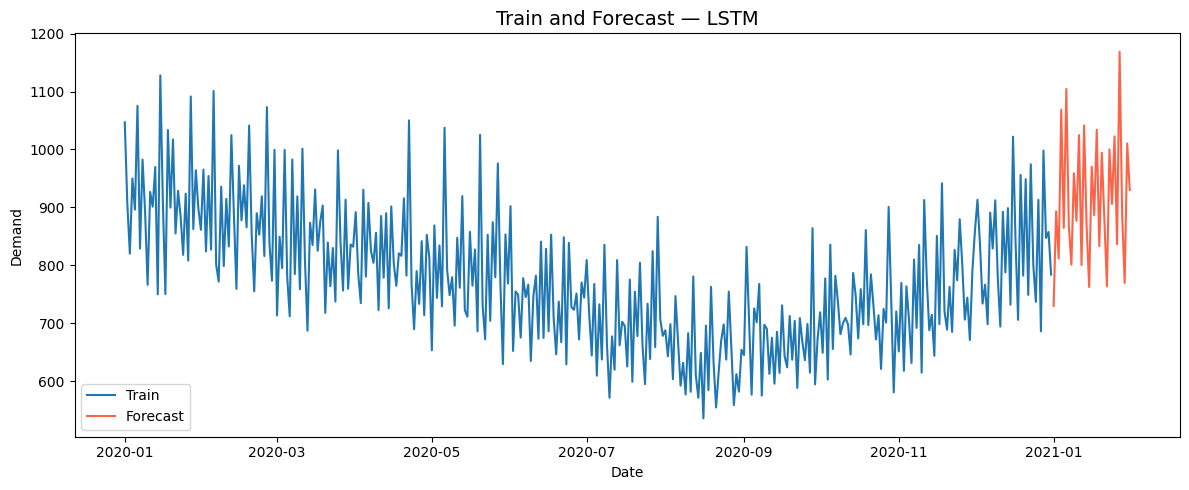

In [33]:
plot_future(df['Demand']['2020':], predictions, "LSTM")